In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, spearmanr

In [2]:
T5 = pd.read_json("./Evaluation/T5.json")
FLAN_T5 = pd.read_json("./Evaluation/FLAN-T5.json")
GPT = pd.read_json("./Evaluation/GPT.json")
BART = pd.read_json("./Evaluation/BART.json")
LED = pd.read_json("./Evaluation/LED.json")

df = pd.concat([T5, FLAN_T5, GPT, BART, LED], ignore_index=True).sample(frac=1, ignore_index=True)
df

,model,dataset,fluency,coherence,informativeness,relevance,factual_consistency
0,bart,cnn,5,5,4,5,5
1,bart,multi-news,5,5,3,5,5
2,gpt,cnn,3,2,4,4,5
3,flan-t5,reddit,4,4,3,4,5
4,t5,reddit,2,2,2,3,3
...,...,...,...,...,...,...,...
311,gpt,reddit,2,1,1,1,2
312,bart,cnn,4,4,3,4,5
313,gpt,cnn,2,1,3,3,5
314,gpt,multi-news,2,1,2,2,1


# Descriptive Statistics

In [3]:
desc_stats = df.groupby('model').agg({
    'fluency': ['mean', 'std'],
    'coherence': ['mean', 'std'],
    'informativeness': ['mean', 'std'],
    'relevance': ['mean', 'std'],
    'factual_consistency': ['mean', 'std'],
})

desc_stats

fluency           coherence           informativeness            \
             mean       std      mean       std            mean       std   
model                                                                       
bart     4.484848  0.684834  4.318182  0.787578        2.803030  0.727899   
flan-t5  4.048387  1.285830  3.693548  1.542711        1.951613  1.031113   
gpt      2.568966  0.840052  2.000000  0.837708        2.862069  0.686927   
led      2.000000  1.040177  1.951613  1.031113        2.241935  1.050924   
t5       3.882353  0.820073  3.514706  0.889284        2.382353  0.773235   

        relevance           factual_consistency            
             mean       std                mean       std  
model                                                      
bart     4.136364  0.839164            4.621212  0.855123  
flan-t5  2.951613  1.360176            4.145161  1.303800  
gpt      3.155172  0.874627            3.724138  0.932702  
led      3.000000  1.254500            3.112903  1.449758  
t5       3.500000  0.906033            4.191176  0.965948

# Visualization

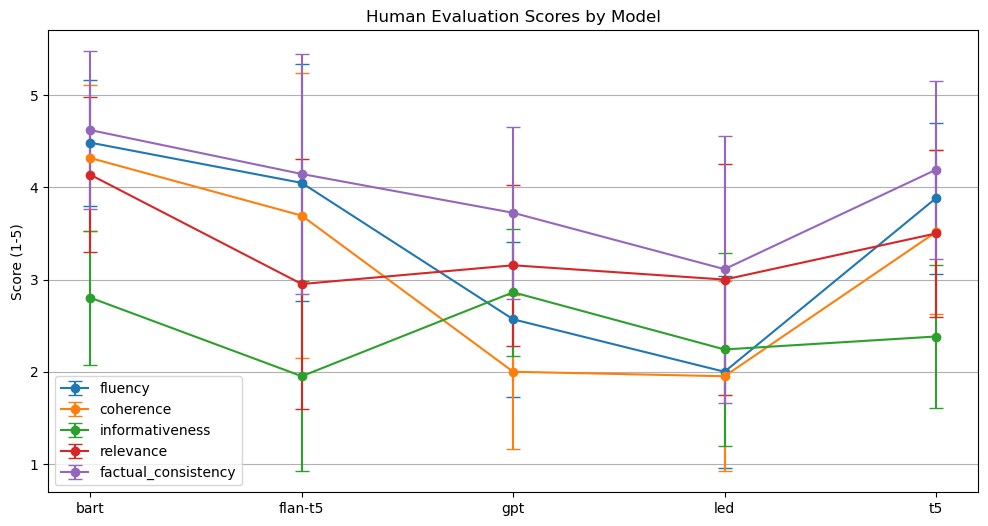

In [4]:
criteria = ['fluency', 'coherence', 'informativeness', 'relevance', 'factual_consistency']

# Bar plot with error bars (mean ± std)
plt.figure(figsize=(12, 6))
for crit in criteria:
    means = df.groupby('model')[crit].mean()
    stds = df.groupby('model')[crit].std()
    plt.errorbar(means.index, means, yerr=stds, capsize=5, marker='o', label=crit)
plt.title('Human Evaluation Scores by Model')
plt.ylabel('Score (1-5)')
plt.legend()
plt.grid(axis='y')
plt.show()

In [5]:
import numpy as np

def radar_plot(data, labels, title):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    # Complete the loop
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(polar=True))
    
    for model in data.index:
        values = data.loc[model].tolist()
        values += values[:1]
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_ylim(1, 5)
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.savefig("./Radar.png")
    plt.show()

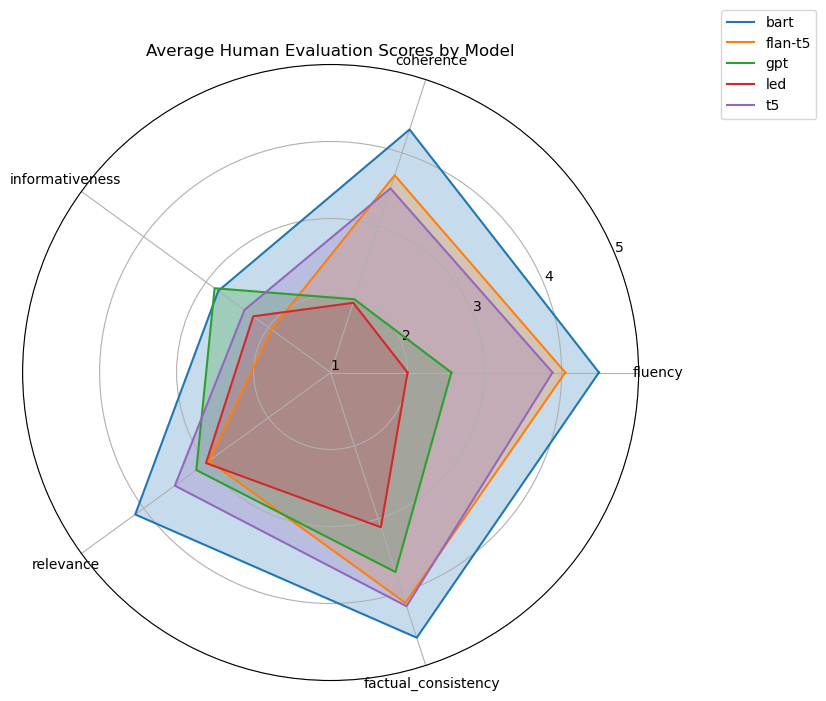

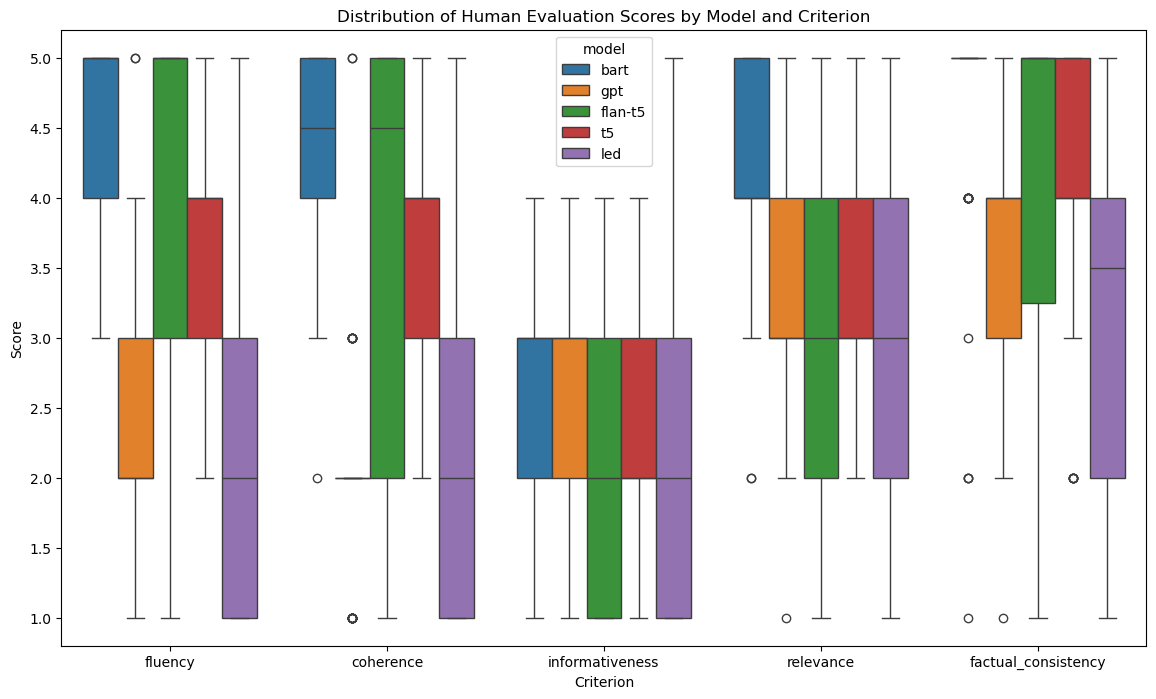

In [6]:
# Prepare mean scores for radar plot
mean_scores = df.groupby('model')[criteria].mean()
radar_plot(mean_scores, criteria, "Average Human Evaluation Scores by Model")

# Boxplot to show distribution
plt.figure(figsize=(14,8))
df_melt = df.melt(id_vars=['model'], value_vars=criteria, var_name='Criterion', value_name='Score')
sns.boxplot(x='Criterion', y='Score', hue='model', data=df_melt)
plt.title('Distribution of Human Evaluation Scores by Model and Criterion')
plt.show()

# Statistical Significance Testing

In [7]:
params = ["fluency", "coherence", "informativeness", "relevance", "factual_consistency"]

models = df['model'].unique()
for param in params:
    print(f"\n\nWilcoxon signed-rank test for pairwise model comparison - {param}:")
    for i in range(len(models)):
        for j in range(i+1, len(models)):
            m1 = models[i]
            m2 = models[j]
            data1 = df[df['model'] == m1][param]
            data2 = df[df['model'] == m2][param]
            # Wilcoxon requires paired samples of same length, so take min length
            min_len = min(len(data1), len(data2))
            stat, p = wilcoxon(data1.sample(min_len, random_state=1).values,
                               data2.sample(min_len, random_state=1).values)
            print(f"{m1} vs {m2}: p-value = {p:.4f}")



Wilcoxon signed-rank test for pairwise model comparison - fluency:
bart vs gpt: p-value = 0.0000
bart vs flan-t5: p-value = 0.0332
bart vs t5: p-value = 0.0004
bart vs led: p-value = 0.0000
gpt vs flan-t5: p-value = 0.0000
gpt vs t5: p-value = 0.0000
gpt vs led: p-value = 0.0008
flan-t5 vs t5: p-value = 0.5479
flan-t5 vs led: p-value = 0.0000
t5 vs led: p-value = 0.0000


Wilcoxon signed-rank test for pairwise model comparison - coherence:
bart vs gpt: p-value = 0.0000
bart vs flan-t5: p-value = 0.0032
bart vs t5: p-value = 0.0000
bart vs led: p-value = 0.0000
gpt vs flan-t5: p-value = 0.0000
gpt vs t5: p-value = 0.0000
gpt vs led: p-value = 0.4740
flan-t5 vs t5: p-value = 0.5614
flan-t5 vs led: p-value = 0.0000
t5 vs led: p-value = 0.0000


Wilcoxon signed-rank test for pairwise model comparison - informativeness:
bart vs gpt: p-value = 0.5248
bart vs flan-t5: p-value = 0.0000
bart vs t5: p-value = 0.0021
bart vs led: p-value = 0.0005
gpt vs flan-t5: p-value = 0.0000
gpt vs t5: p-va